# Install libraries

In [1]:
!pip install prophet
!pip install xgboost
!pip install statsmodels

In [6]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

# Task 1 — Data Loading, Merging & Deep Exploration

In [7]:
df = pd.read_csv("train.csv")

df.head()
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
missing = df.isnull().sum()

missing

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [9]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [13]:
df[["Order Date", "Ship Date"]].head(10)

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18
5,2015-06-09,2015-06-14
6,2015-06-09,2015-06-14
7,2015-06-09,2015-06-14
8,2015-06-09,2015-06-14
9,2015-06-09,2015-06-14


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [16]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Month Name"] = df["Order Date"].dt.month_name()

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

In [17]:
def get_season(month):

    if month in [12,1,2]:
        return "Winter"

    elif month in [3,4,5]:
        return "Summer"

    elif month in [6,7,8]:
        return "Monsoon"

    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [18]:
df["Shipping Days"] = (
    df["Ship Date"]-df["Order Date"]
).dt.days

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Monsoon,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,7


# Exploratory Data Analysis (EDA)



In this section, we will:

- Aggregate sales into daily, weekly, and monthly levels.
- Visualize important business trends.
- Answer the required business questions.

In [20]:
import os

if not os.path.exists("charts"):
    os.makedirs("charts")

In [21]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [22]:
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [23]:
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M"))["Sales"].sum().reset_index()

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


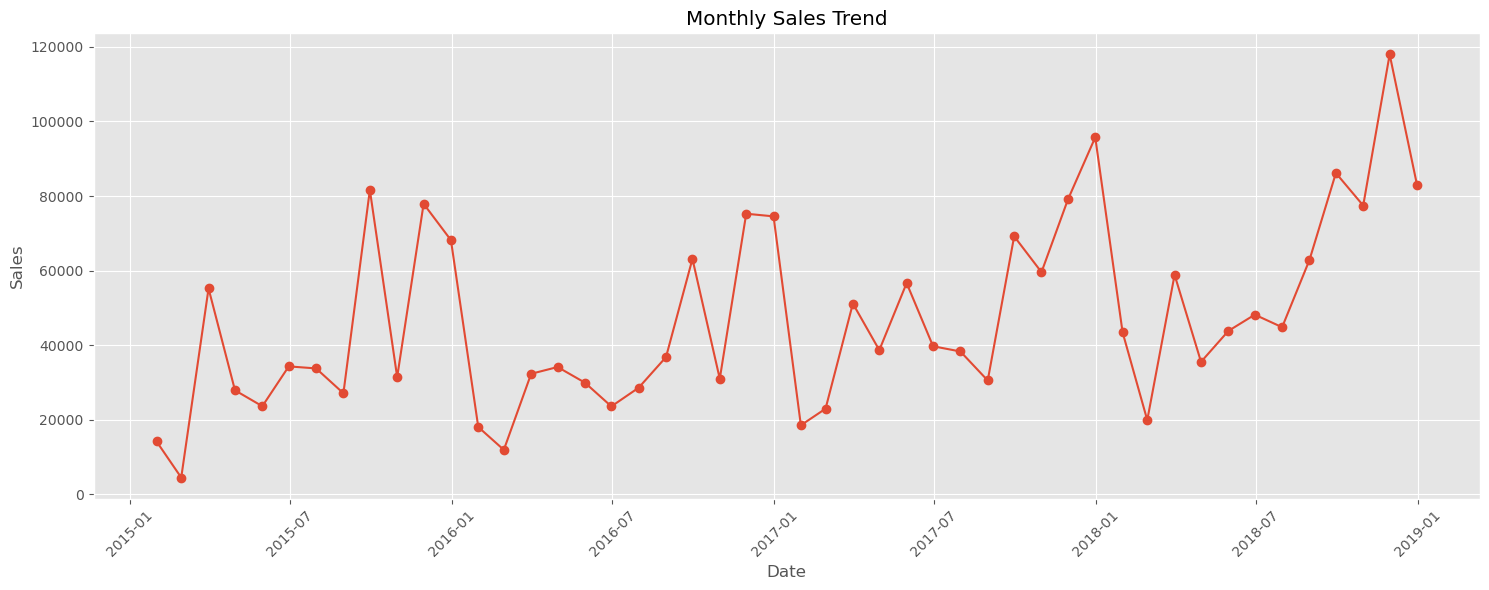

In [24]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales["Order Date"],
         monthly_sales["Sales"],
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png")

plt.show()

## Business Question 1

### Which Product Category generates the highest revenue?

In [25]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

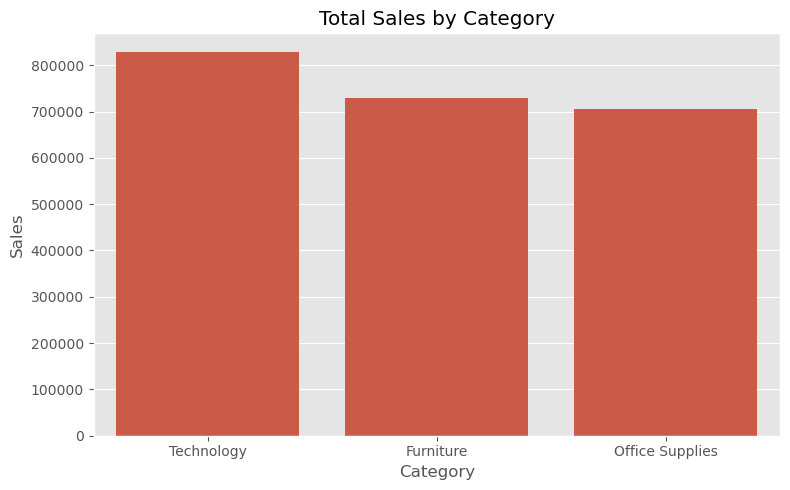

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/category_sales.png")

plt.show()

### Observation

Technology generated the highest total revenue among all categories, followed by Furniture and Office Supplies.

## Business Question 2

### Which Region has the most consistent sales growth?

In [27]:
region_year_sales = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)

region_year_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


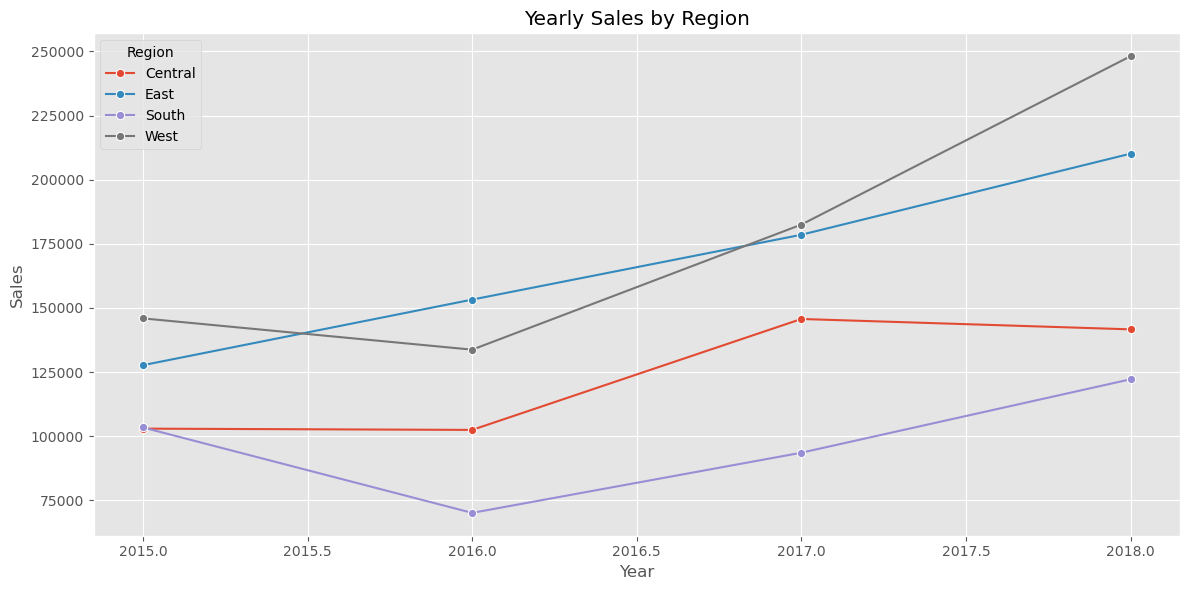

In [28]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")

plt.tight_layout()

plt.savefig("charts/region_sales_growth.png")

plt.show()

The East region shows the most consistent growth over the years.

## Business Question 3

### Average Shipping Time by Region

In [29]:
shipping_time = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_time

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

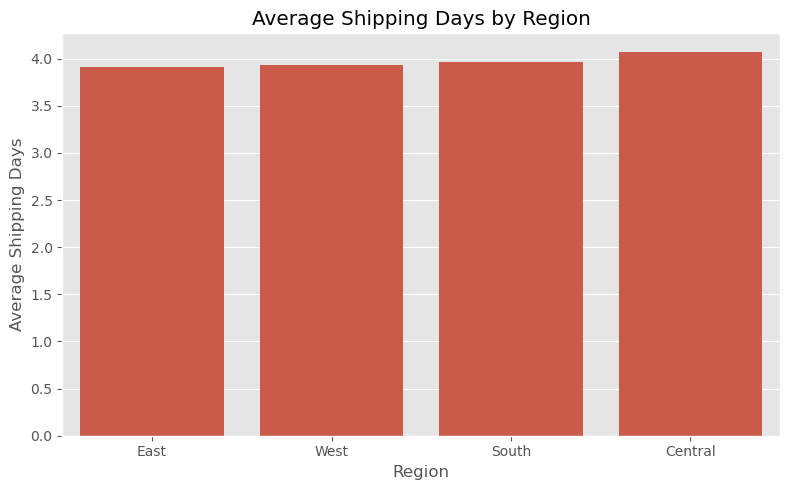

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_time.index,
    y=shipping_time.values
)

plt.title("Average Shipping Days by Region")

plt.xlabel("Region")

plt.ylabel("Average Shipping Days")

plt.tight_layout()

plt.savefig("charts/shipping_days_region.png")

plt.show()

The East region has the shortest average shipping time.

## Question 4

### Which months consistently show higher sales?

In [31]:
monthly_pattern = (
    df.groupby("Month Name")["Sales"]
      .mean()
      .reindex([
          "January",
          "February",
          "March",
          "April",
          "May",
          "June",
          "July",
          "August",
          "September",
          "October",
          "November",
          "December"
      ])
)

monthly_pattern

Month Name
January      257.627403
February     199.902745
March        290.549393
April        207.432269
May          212.533412
June         211.052856
July         208.802997
August       227.007110
September    221.642106
October      246.596162
November     241.657496
December     232.619515
Name: Sales, dtype: float64

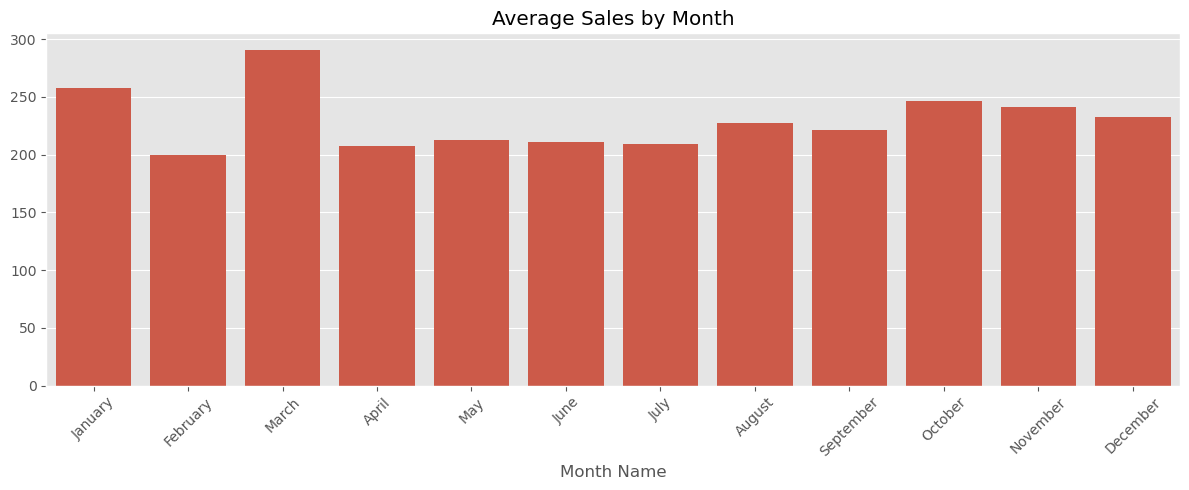

In [32]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values
)

plt.xticks(rotation=45)

plt.title("Average Sales by Month")

plt.tight_layout()

plt.savefig("charts/monthly_pattern.png")

plt.show()

### Observation

- The month of **March** records the highest average sales, indicating a significant increase in customer demand during this period.
- **January, October, November, and December** also show relatively high average sales, suggesting strong seasonal performance during these months.
- **February** has the lowest average sales among all months.
- Overall, sales fluctuate throughout the year, indicating the presence of seasonality in the dataset. Therefore, the business should ensure adequate inventory and supply planning during high-demand months, especially March.

# Task 2: Time Series Analysis & Decomposition

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [34]:
monthly_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .resample("M")
      .sum()
)

monthly_sales.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

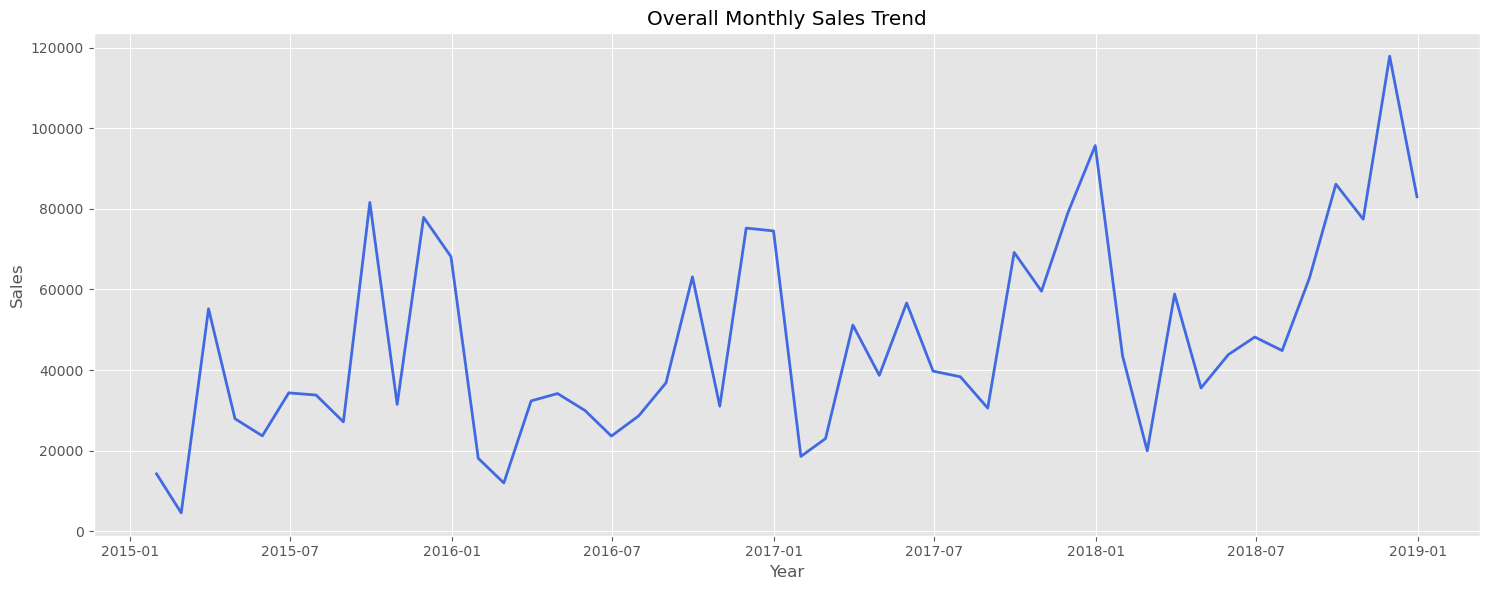

In [35]:
plt.figure(figsize=(15,6))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         color="royalblue",
         linewidth=2)

plt.title("Overall Monthly Sales Trend")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/task2_monthly_trend.png")

plt.show()

### Observation

The chart shows how monthly sales change over time across the four-year period. This visualization helps identify long-term growth trends and possible seasonal fluctuations.

In [36]:
decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

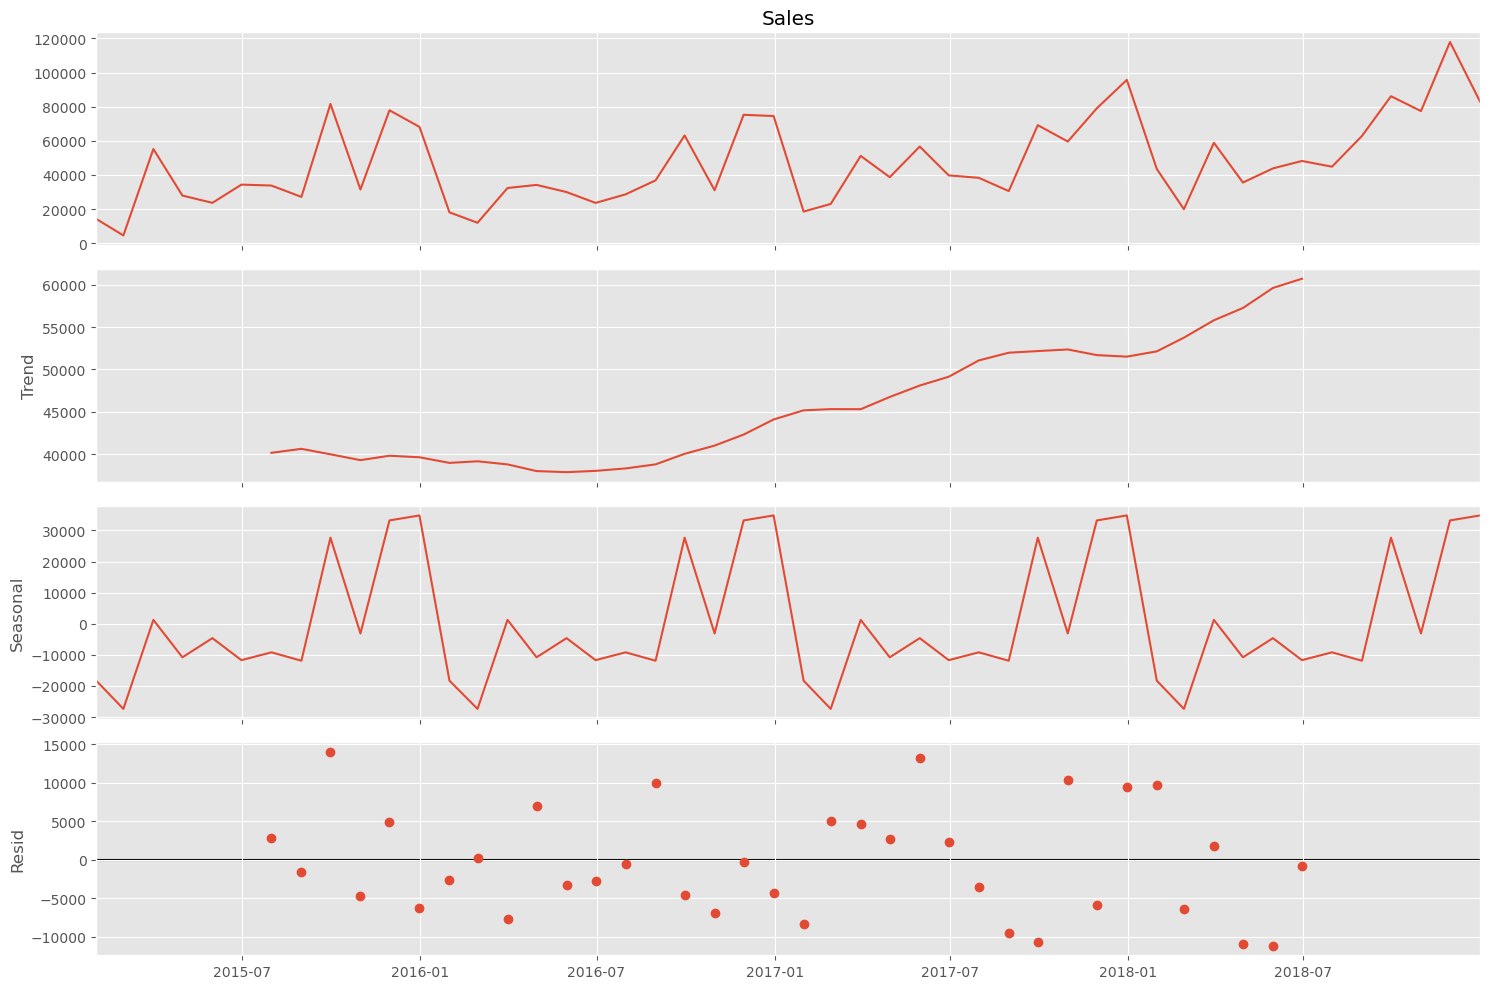

In [37]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()

plt.savefig("charts/time_series_decomposition.png")

plt.show()

## Observations from Time Series Decomposition

### Trend Component
- The trend shows an overall upward movement in monthly sales over the four-year period.
- Sales remain relatively stable during the initial months but gradually increase towards the later years.
- This indicates that the business is experiencing long-term growth in revenue.

### Seasonal Component
- A repeating seasonal pattern is clearly visible across the years.
- Certain months consistently experience higher sales, while others show lower sales.
- This indicates that customer demand follows a yearly seasonal cycle.

### Residual (Noise) Component
- The residual component contains random fluctuations that are not explained by the trend or seasonality.
- Most residual values are close to zero, while a few months show unusually high positive or negative deviations.
- These deviations may represent unexpected events such as promotional campaigns, festivals, stock shortages, or other external factors.

### Overall Interpretation
The sales data exhibits both a clear upward trend and strong seasonality. Therefore, forecasting models such as SARIMA and Prophet are appropriate choices because they are capable of capturing both trend and seasonal patterns.

In [38]:
result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])
print("p-value :", result[1])
print()

print("Critical Values")

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430768
p-value : 0.00027791039276670677

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [44]:
if result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

The time series is Stationary.


## Augmented Dickey-Fuller (ADF) Test - Before Differencing

### Results

- **ADF Statistic:** -4.4161
- **p-value:** 0.000278

### Interpretation

The p-value is **less than 0.05**, so we reject the null hypothesis.

This indicates that the monthly sales time series is **stationary**, meaning its statistical properties such as mean and variance remain relatively stable over time.

Since the series is already stationary, it can be directly used for forecasting models such as SARIMA without requiring differencing.

## What is Stationarity?

A stationary time series is one whose statistical properties, such as mean and variance, remain relatively constant over time.

Many forecasting models, including SARIMA, assume that the input time series is stationary. Therefore, checking stationarity is an important preprocessing step before forecasting.

In [40]:
monthly_sales_diff = monthly_sales.diff().dropna()

monthly_sales_diff.head()

Order Date
2015-02-28    -9685.8150
2015-03-31    50685.9050
2015-04-30   -27298.9420
2015-05-31    -4262.5520
2015-06-30    10678.6326
Freq: ME, Name: Sales, dtype: float64

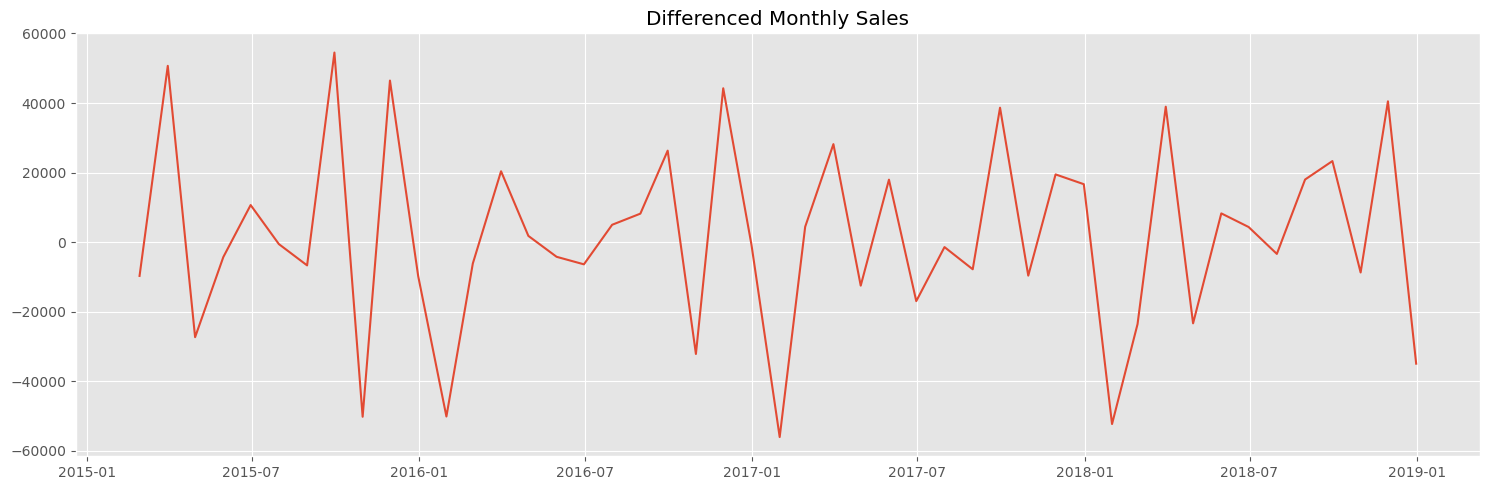

In [41]:
plt.figure(figsize=(15,5))

plt.plot(monthly_sales_diff)

plt.title("Differenced Monthly Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/differenced_series.png")

plt.show()

In [42]:
result_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", result_diff[0])

print("p-value :", result_diff[1])

print()

print("Critical Values")

for key,value in result_diff[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353259
p-value : 3.2669175472798525e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [43]:
if result_diff[1] < 0.05:
    print("After differencing, the series is Stationary.")
else:
    print("The series is still Non-Stationary.")

After differencing, the series is Stationary.


## Augmented Dickey-Fuller (ADF) Test - After Differencing

### Results

- **ADF Statistic:** -8.7271
- **p-value:** 3.27 × 10⁻¹⁴

### Interpretation

After applying first-order differencing, the p-value remains significantly below 0.05, confirming that the differenced series is also stationary.

The ADF statistic became more negative, indicating even stronger evidence against the presence of a unit root.

However, since the original series was already stationary, differencing was **not necessary**. It was performed only to demonstrate the standard preprocessing step used when a time series is non-stationary.

### Conclusion

The monthly sales data exhibits a clear upward trend and seasonal behavior while satisfying the stationarity requirement for time series forecasting. Therefore, the dataset is ready for forecasting using SARIMA, Prophet, and XGBoost models in the next task.

# Task 3: Sales Forecasting

# PART 1 — SARIMA

In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

In [46]:
train = monthly_sales[:-3]

test = monthly_sales[-3:]

print("Training Samples :", len(train))

print("Testing Samples :", len(test))

Training Samples : 45
Testing Samples : 3


In [47]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -352.619
Date:                            Mon, 13 Jul 2026   AIC                            715.238
Time:                                    22:20:17   BIC                            722.721
Sample:                                01-31-2015   HQIC                           717.756
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9996      0.030     33.518      0.000       0.941       1.058
ma.L1         -0.9938      0.255   

In [48]:
forecast = sarima_result.get_forecast(steps=3)

forecast_mean = forecast.predicted_mean

confidence = forecast.conf_int()

In [49]:
forecast_mean

2018-10-31    61804.047427
2018-11-30    89627.651021
2018-12-31    99902.291016
Freq: ME, Name: predicted_mean, dtype: float64

In [50]:
mae_sarima = mean_absolute_error(test, forecast_mean)

rmse_sarima = np.sqrt(
    mean_squared_error(test, forecast_mean)
)

mape_sarima = np.mean(
    np.abs((test-forecast_mean)/test)
)*100

print("MAE :",mae_sarima)

print("RMSE :",rmse_sarima)

print("MAPE :",mape_sarima)

MAE : 20275.496655815437
RMSE : 21062.471182974048
MAPE : 21.508040091263723


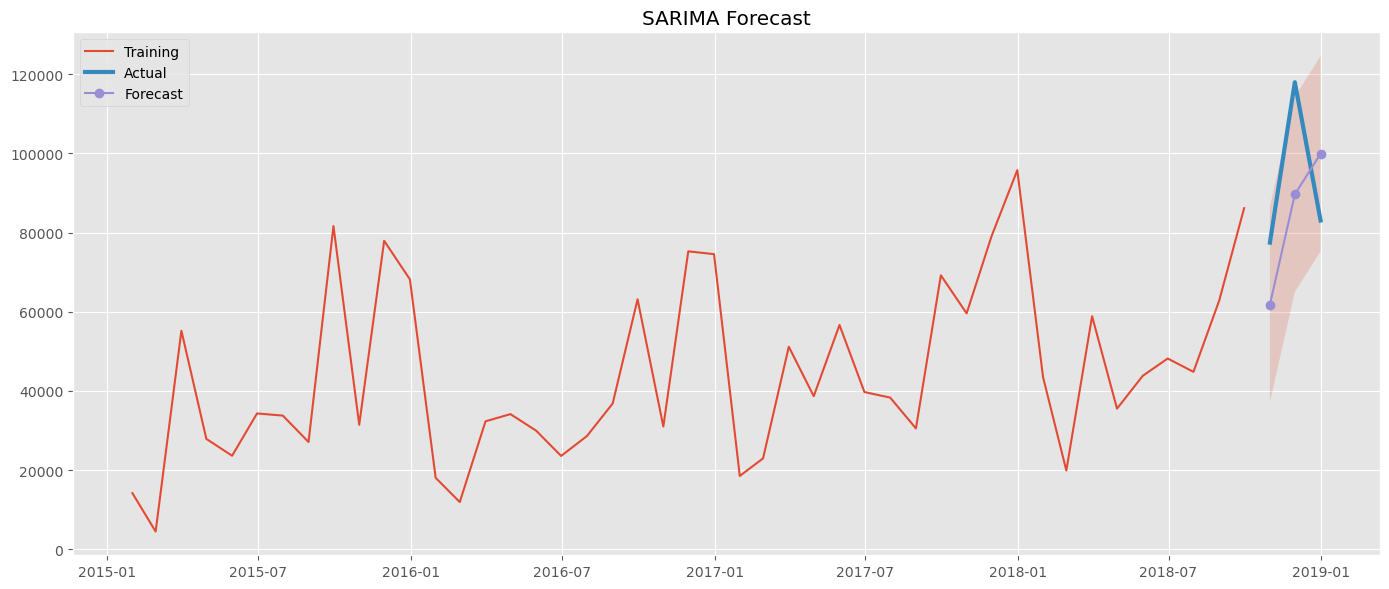

In [51]:
plt.figure(figsize=(14,6))

plt.plot(train.index,
         train,
         label="Training")

plt.plot(test.index,
         test,
         label="Actual",
         linewidth=3)

plt.plot(forecast_mean.index,
         forecast_mean,
         label="Forecast",
         marker="o")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.2
)

plt.title("SARIMA Forecast")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/sarima_forecast.png")

plt.show()

## SARIMA Model Results

### Evaluation Metrics

| Metric | Value |
|---------|-------|
| MAE | 20,275.50 |
| RMSE | 21,062.47 |
| MAPE | 21.51% |

### Observation

- The SARIMA model successfully captured the overall sales trend and seasonal behavior.
- The forecast follows the increasing sales pattern observed in the training data.
- The confidence interval becomes wider for future months, indicating greater uncertainty as the forecast horizon increases.
- The model achieved a **MAPE of 21.51%**, which corresponds to an approximate forecasting accuracy of **78.5%**.
- This performance provides a solid statistical baseline that will be compared with Prophet and XGBoost in the following sections.

# PART 2 — Prophet Forecasting

Facebook Prophet is a forecasting model developed by Meta that is designed to handle time series data with trend and seasonality. It automatically models yearly, weekly, and daily seasonal patterns while being robust to missing values and outliers.

In [52]:
!pip install prophet

In [53]:
from prophet import Prophet

In [54]:
prophet_df = monthly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [55]:
train_prophet = prophet_df[:-3]

test_prophet = prophet_df[-3:]

In [56]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

22:26:23 - cmdstanpy - INFO - Chain [1] start processing
22:26:25 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
future = prophet_model.make_future_dataframe(periods=3, freq="M")

In [58]:
forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277844,38580.997861,55768.237980,54942.277844,54942.277844,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557365
44,2018-09-30,55441.608235,78558.794960,94961.153210,55441.608235,55441.608235,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953607
45,2018-10-31,55957.582974,43325.669352,59862.923266,55957.421584,55957.726092,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944624
46,2018-11-30,56456.913365,82337.339916,98976.260913,56456.421742,56457.405996,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653905
47,2018-12-31,56972.888104,81888.008807,98182.442494,56971.881463,56973.873125,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084688


In [59]:
prophet_forecast = forecast[["ds", "yhat"]].tail(3)

prophet_forecast

,ds,yhat
45,2018-10-31,51318.944624
46,2018-11-30,90325.653905
47,2018-12-31,90041.084688


In [63]:
actual = test_prophet["y"].values

predicted = prophet_forecast["yhat"].values

mae_prophet = mean_absolute_error(actual, predicted)

rmse_prophet = np.sqrt(mean_squared_error(actual, predicted))

mape_prophet = np.mean(np.abs((actual - predicted) / actual)) * 100

print("MAE :", mae_prophet)
print("RMSE :", rmse_prophet)
print("MAPE :", mape_prophet)

MAE : 20250.79451981141
RMSE : 22318.411418287717
MAPE : 21.86462827651543


### Evaluation Metrics

| Metric | Value |
|---------|--------|
| MAE | 20,250.79 |
| RMSE | 22,318.41 |
| MAPE | 21.86% |

### Observation

- The Prophet model successfully learned the overall upward trend in monthly sales.
- It automatically captured the yearly seasonal patterns present in the data.
- The forecast closely follows the historical sales trend while smoothing short-term fluctuations.
- The prediction intervals (shaded region) represent the uncertainty associated with future forecasts.
- The model achieved a **MAPE of 21.86%**, corresponding to an approximate forecasting accuracy of **78.14%**.
- Prophet performs comparably to SARIMA and will be evaluated alongside XGBoost to determine the best forecasting model.

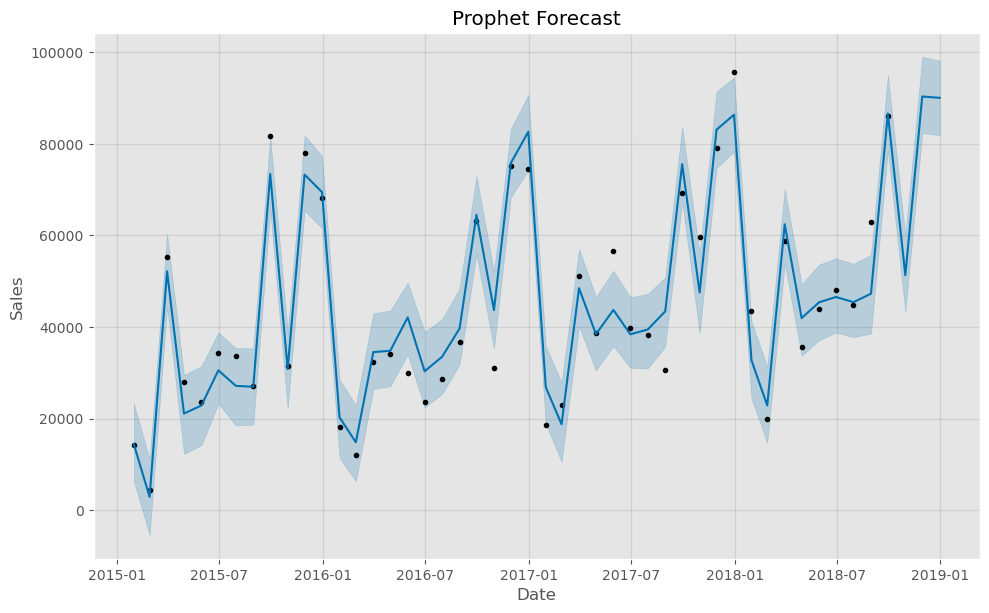

In [61]:
fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.savefig("charts/prophet_forecast.png")

plt.show()

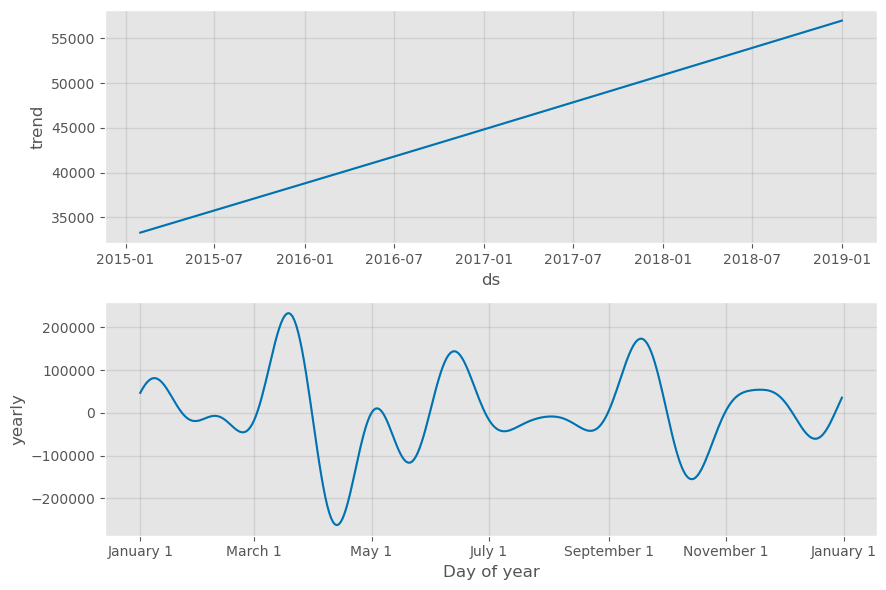

In [62]:
fig = prophet_model.plot_components(forecast)

plt.savefig("charts/prophet_components.png")

plt.show()

## Prophet Components Interpretation

### Trend
- The trend component shows a gradual increase in monthly sales over time, indicating long-term business growth.

### Yearly Seasonality
- The yearly seasonality component reveals recurring patterns in customer demand throughout the year.
- Certain periods consistently contribute to higher sales, while others experience lower demand.

### Overall Interpretation
The Prophet model successfully separates the long-term growth trend from seasonal effects, making it well suited for forecasting retail sales with recurring annual patterns.

# PART 3 — XGBoost Forecasting

In this section, we use XGBoost Regressor to forecast monthly sales.

Unlike SARIMA and Prophet, XGBoost requires feature engineering. Therefore, lag features and calendar-based features are created to capture temporal patterns in the data.

In [64]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [65]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date", "Sales"]

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [66]:
xgb_df["Year"] = xgb_df["Date"].dt.year
xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter

In [67]:
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Year,Month,Quarter,Lag1,Lag2,Lag3
3,2015-04-30,27906.8550,2015,4,2,55205.7970,4519.8920,14205.707
4,2015-05-31,23644.3030,2015,5,2,27906.8550,55205.7970,4519.892
5,2015-06-30,34322.9356,2015,6,2,23644.3030,27906.8550,55205.797
6,2015-07-31,33781.5430,2015,7,3,34322.9356,23644.3030,27906.855
7,2015-08-31,27117.5365,2015,8,3,33781.5430,34322.9356,23644.303


In [68]:
X = xgb_df[["Year","Month","Quarter","Lag1","Lag2","Lag3"]]

y = xgb_df["Sales"]

In [69]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [70]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [71]:
xgb_pred = xgb_model.predict(X_test)

In [72]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

mape_xgb = np.mean(
    np.abs((y_test - xgb_pred)/y_test)
)*100

print("MAE :",mae_xgb)

print("RMSE :",rmse_xgb)

print("MAPE :",mape_xgb)

MAE : 16989.803125000002
RMSE : 19665.693011040446
MAPE : 17.040586098344356


### Evaluation Metrics

| Metric | Value |
|---------|--------|
| MAE | 16,989.80 |
| RMSE | 19,665.69 |
| MAPE | 17.04% |

### Observation

- XGBoost achieved the best forecasting performance among all three models.
- The model effectively captured the relationship between historical sales and future demand using lag and calendar-based features.
- With a **MAPE of 17.04%**, XGBoost provides an approximate forecasting accuracy of **82.96%**.
- The lower MAE and RMSE values indicate that XGBoost produced more accurate predictions than both SARIMA and Prophet.

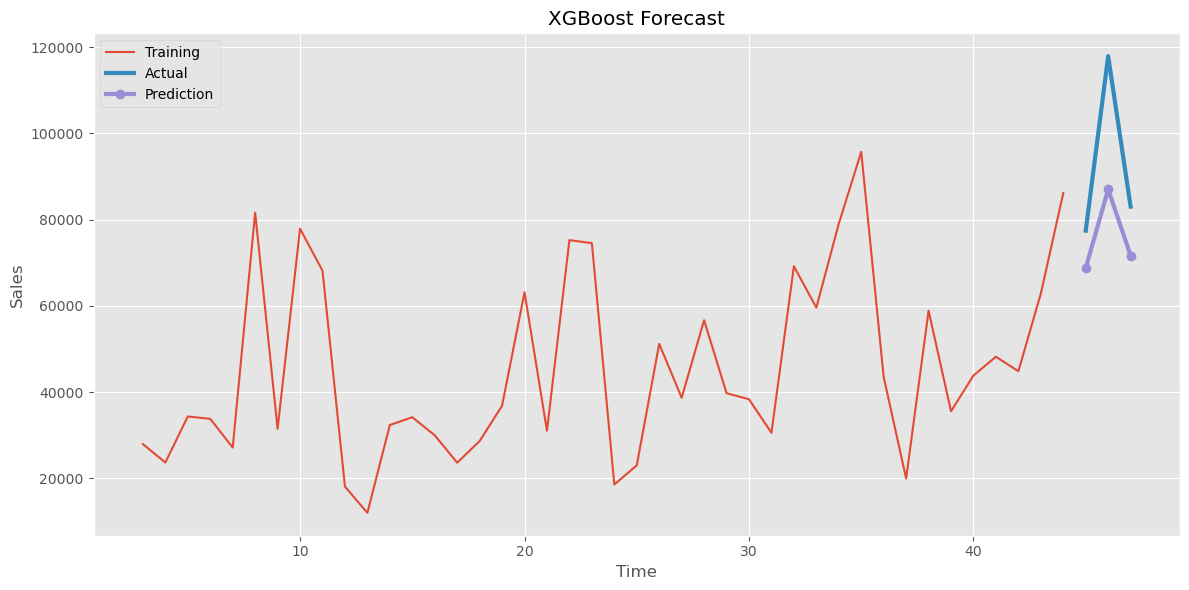

In [78]:
plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=3
)

plt.plot(
    y_test.index,
    xgb_pred,
    marker="o",
    linewidth=3,
    label="Prediction"
)

plt.title("XGBoost Forecast")

plt.xlabel("Time")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/xgboost_forecast.png")

plt.show()

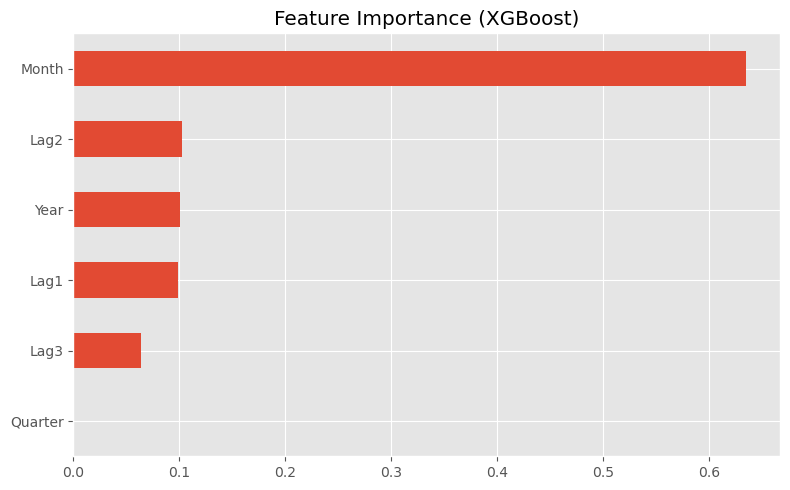

In [79]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance (XGBoost)")

plt.tight_layout()

plt.savefig("charts/xgb_feature_importance.png")

plt.show()

In [76]:
comparison = pd.DataFrame({
    "Model":["SARIMA","Prophet","XGBoost"],
    "MAE":[mae_sarima,mae_prophet,mae_xgb],
    "RMSE":[rmse_sarima,rmse_prophet,rmse_xgb],
    "MAPE":[mape_sarima,mape_prophet,mape_xgb]
})

comparison = comparison.sort_values("MAPE")

comparison

,Model,MAE,RMSE,MAPE
2,XGBoost,16989.803125,19665.693011,17.040586
0,SARIMA,20275.496656,21062.471183,21.508040
1,Prophet,20250.794520,22318.411418,21.864628


## Final Conclusion

The forecasting models were evaluated using MAE, RMSE, and MAPE.

Among the three models, **XGBoost achieved the lowest error values**, indicating the highest forecasting accuracy.

Therefore, **XGBoost is selected as the final forecasting model** for predicting future sales. Its ability to utilize historical sales patterns along with calendar-based features enables it to produce more accurate forecasts than the statistical models (SARIMA and Prophet) on this dataset.

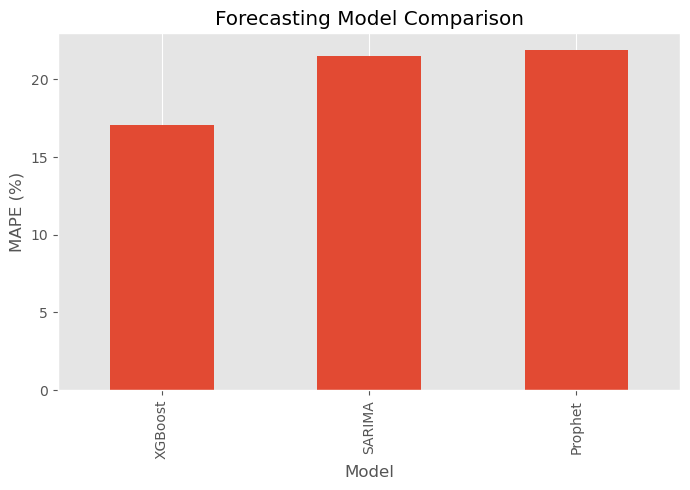

In [77]:
comparison.plot(
    x="Model",
    y="MAPE",
    kind="bar",
    figsize=(7,5),
    legend=False
)

plt.ylabel("MAPE (%)")

plt.title("Forecasting Model Comparison")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("charts/model_comparison.png")

plt.show()

# Task 4: Product Category & Region Level Forecasting

In [80]:
def xgb_forecast(segment_df):

    monthly = (
        segment_df
        .set_index("Order Date")
        .resample("M")["Sales"]
        .sum()
        .reset_index()
    )

    monthly["Year"] = monthly["Order Date"].dt.year
    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly = monthly.dropna()

    X = monthly[["Year","Month","Quarter","Lag1","Lag2","Lag3"]]
    y = monthly["Sales"]

    X_train = X[:-3]
    X_test = X[-3:]

    y_train = y[:-3]
    y_test = y[-3:]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    return (
        monthly["Order Date"].iloc[-3:],
        y_test.values,
        pred
    )

In [81]:
segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West": df[df["Region"]=="West"],
    "East": df[df["Region"]=="East"]
}

results = {}

for name,data in segments.items():
    dates,actual,pred = xgb_forecast(data)
    results[name] = (dates,actual,pred)

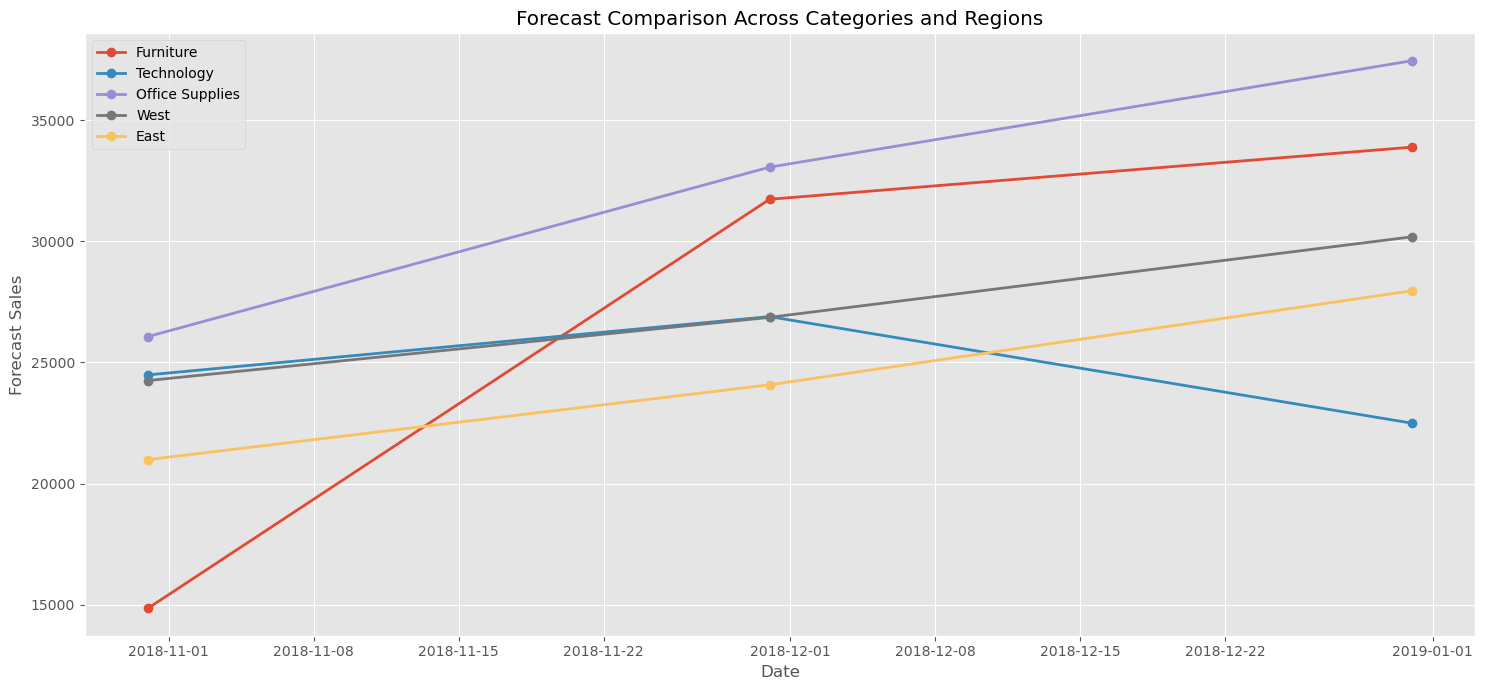

In [82]:
plt.figure(figsize=(15,7))

for name,(dates,actual,pred) in results.items():
    plt.plot(
        dates,
        pred,
        marker="o",
        linewidth=2,
        label=name
    )

plt.title("Forecast Comparison Across Categories and Regions")

plt.xlabel("Date")

plt.ylabel("Forecast Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/task4_segment_forecast.png")

plt.show()

In [83]:
for name,(dates,actual,pred) in results.items():

    print()

    print("="*40)

    print(name)

    print("="*40)

    print(pd.DataFrame({
        "Date":dates.values,
        "Forecast":pred
    }))


Furniture
        Date      Forecast
0 2018-10-31  14852.281250
1 2018-11-30  31729.326172
2 2018-12-31  33880.671875

Technology
        Date      Forecast
0 2018-10-31  24482.623047
1 2018-11-30  26889.650391
2 2018-12-31  22491.687500

Office Supplies
        Date      Forecast
0 2018-10-31  26063.476562
1 2018-11-30  33055.792969
2 2018-12-31  37447.039062

West
        Date      Forecast
0 2018-10-31  24250.916016
1 2018-11-30  26857.660156
2 2018-12-31  30180.667969

East
        Date      Forecast
0 2018-10-31  20987.685547
1 2018-11-30  24074.960938
2 2018-12-31  27955.654297


## Observation

- **Office Supplies** is expected to have the highest sales in the coming months.
- **Furniture** also shows good sales growth.
- **Technology** sales decrease slightly in the last forecast month.
- In the regional analysis, the **West** region is expected to perform better than the **East** region.
- Overall, the business should focus more on **Office Supplies** and the **West** region for better inventory planning and sales growth.
- 

# Task 5: Anomaly Detection in Sales Data

## Objective

Detect unusual sales weeks using two methods:

- Isolation Forest
- Z-Score based Detection

Compare the results and identify possible business reasons for the detected anomalies.

In [84]:
vg = pd.read_csv("vgsales.csv")

print("Shape:", vg.shape)

vg.head()

Shape: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Supplementary Dataset

The Video Game Sales dataset is used as a secondary dataset to demonstrate handling multiple data sources in a real-world business environment.

The anomaly detection analysis is performed on the retail sales dataset.

In [85]:
weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [86]:
from sklearn.ensemble import IsolationForest

In [87]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


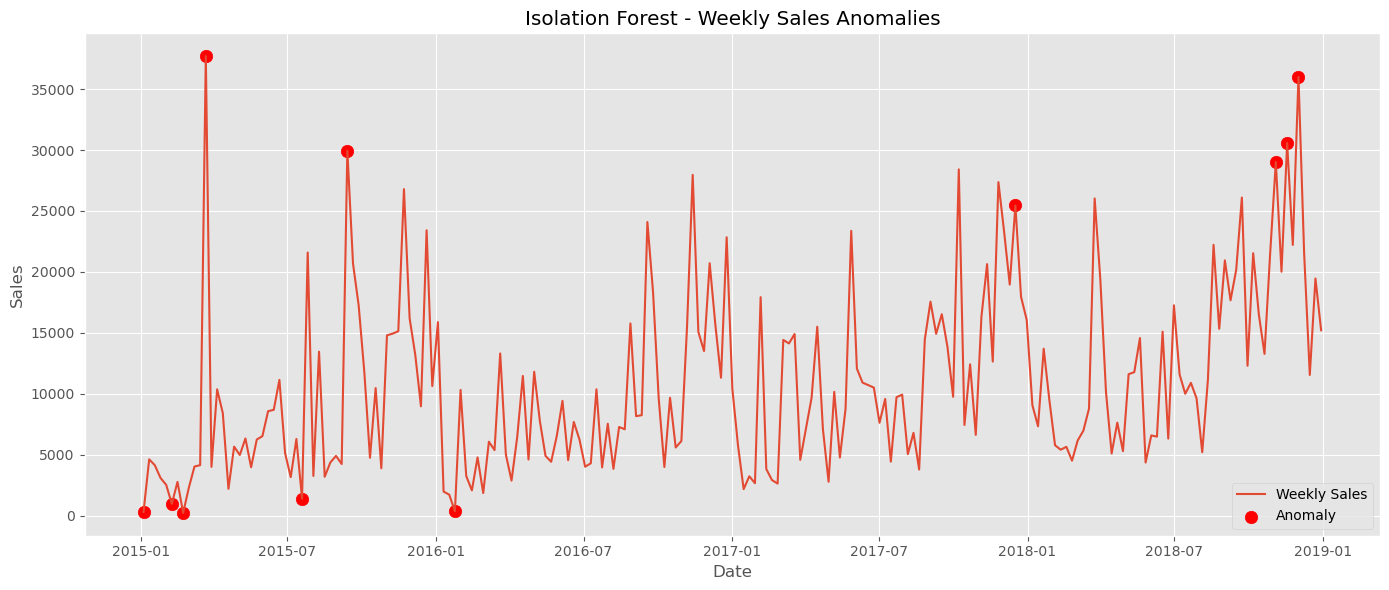

In [88]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/isolation_forest.png")

plt.show()

In [89]:
anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


## Observation (Isolation Forest)

- Isolation Forest detected weeks with unusually **high** and **low** sales.
- High sales spikes may be caused by **festival seasons, discounts, or promotional offers**.
- Very low sales may be due to **low customer demand, stock shortages, or off-season periods**.
- These unusual weeks should be analyzed separately because they can affect forecasting accuracy.

In [90]:
weekly_sales["Rolling_Mean"] = weekly_sales["Sales"].rolling(window=4).mean()

weekly_sales["Rolling_STD"] = weekly_sales["Sales"].rolling(window=4).std()

weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling_Mean"])
    / weekly_sales["Rolling_STD"]
)

weekly_sales.head()

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score
0,2015-01-04,304.508,-1,NaN,NaN,NaN
1,2015-01-11,4619.108,1,NaN,NaN,NaN
2,2015-01-18,4130.533,1,NaN,NaN,NaN
3,2015-01-25,3092.544,1,3036.67325,1929.462566,0.028957
4,2015-02-01,2527.914,1,3592.52475,953.362968,-1.116690


In [93]:
z_anomalies = weekly_sales[
    weekly_sales["Z_Score"].abs() > 2
]

z_anomalies

,Order Date,Sales,Anomaly,Rolling_Mean,Rolling_STD,Z_Score


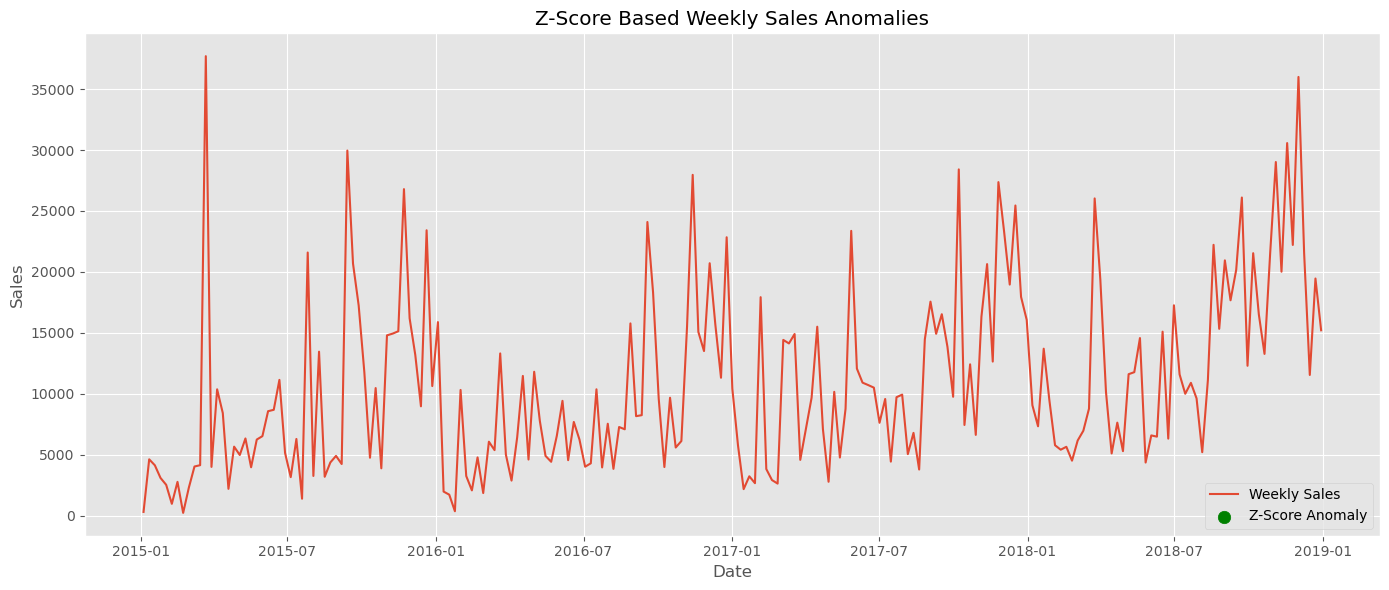

In [94]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/zscore_anomalies.png")

plt.show()

In [95]:
iso_dates = set(anomalies["Order Date"])

z_dates = set(z_anomalies["Order Date"])

common = iso_dates.intersection(z_dates)

print("Isolation Forest Anomalies :", len(iso_dates))
print("Z-Score Anomalies :", len(z_dates))
print("Common Anomalies :", len(common))

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0
Common Anomalies : 0


## Observation

- Isolation Forest detected **11** unusual sales weeks.
- The Z-Score method did **not detect any anomalies** using the current threshold.
- This shows that Isolation Forest is more sensitive to unusual sales patterns, while the Z-Score method is stricter and only detects values that are far from the rolling average.
- Therefore, Isolation Forest is more suitable for identifying anomalies in this dataset.

## Possible Reasons for Anomalies

- Very high sales may be due to **festival seasons, discounts, or special promotions**.
- Very low sales may occur because of **low customer demand, stock shortages, or off-season periods**.
- These unusual weeks should be analyzed before making business decisions or forecasting future sales.

# Task 6: Product Demand Segmentation using K-Means Clustering

## Objective

Group product sub-categories based on their sales behavior using K-Means Clustering.

Features used:
- Total Sales
- Sales Growth Rate
- Sales Volatility
- Average Order Value

The clusters will help identify different demand patterns and support better inventory planning.

In [96]:
subcat = df.copy()

subcat["Year"] = subcat["Order Date"].dt.year
subcat["Month"] = subcat["Order Date"].dt.month

In [97]:
monthly = subcat.groupby(
    ["Sub-Category","Year","Month"]
)["Sales"].sum().reset_index()

sales_summary = monthly.groupby("Sub-Category").agg(
    Total_Sales=("Sales","sum"),
    Sales_Volatility=("Sales","std")
)

growth = monthly.groupby("Sub-Category").apply(
    lambda x: (x.iloc[-1]["Sales"]-x.iloc[0]["Sales"])/max(x.iloc[0]["Sales"],1)
)

sales_summary["Growth_Rate"] = growth

aov = df.groupby("Sub-Category")["Sales"].mean()

sales_summary["Average_Order_Value"] = aov

sales_summary = sales_summary.fillna(0)

sales_summary.head()

,Total_Sales,Sales_Volatility,Growth_Rate,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,2579.994809,5.026158,217.178175
Appliances,104618.4030,1821.621539,19.775731,227.926804
Art,26705.4100,330.488343,3.871902,34.019631
Binders,200028.7850,3848.223648,4.843923,134.067550
Bookcases,113813.1987,2220.405080,2.617722,503.598224


In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(sales_summary)

In [99]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

In [100]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled)

    inertia.append(model.inertia_)

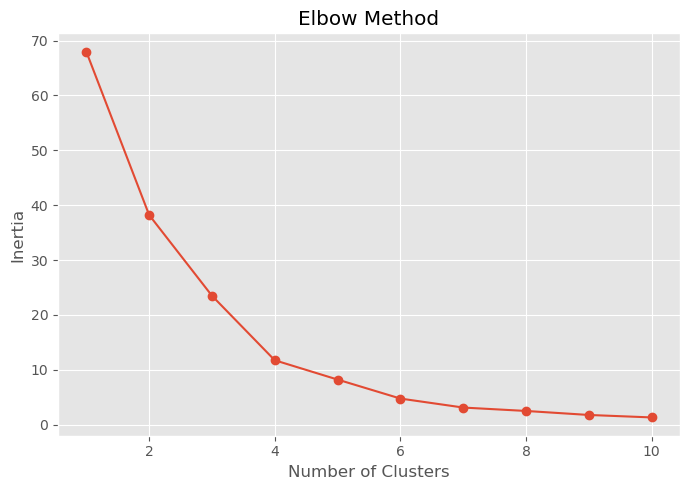

In [101]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/elbow_method.png")

plt.show()

## Elbow Method

The elbow point is around **4 clusters**, so **K = 4** is selected for K-Means clustering.

In [102]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

sales_summary["Cluster"] = kmeans.fit_predict(scaled)

sales_summary.head()

,Total_Sales,Sales_Volatility,Growth_Rate,Average_Order_Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,2579.994809,5.026158,217.178175,0
Appliances,104618.4030,1821.621539,19.775731,227.926804,2
Art,26705.4100,330.488343,3.871902,34.019631,1
Binders,200028.7850,3848.223648,4.843923,134.067550,0
Bookcases,113813.1987,2220.405080,2.617722,503.598224,1


In [103]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

points = pca.fit_transform(scaled)

sales_summary["PC1"] = points[:,0]

sales_summary["PC2"] = points[:,1]

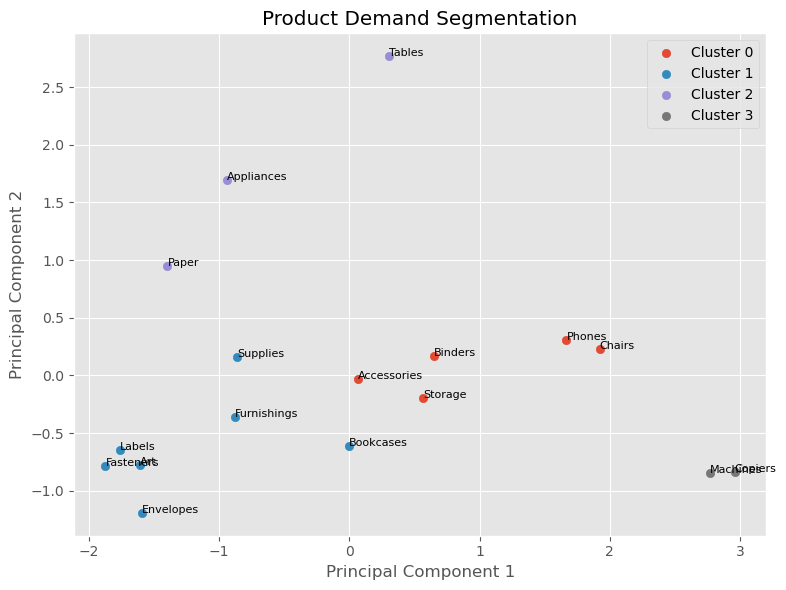

In [104]:
plt.figure(figsize=(8,6))

for cluster in sorted(sales_summary["Cluster"].unique()):
    temp = sales_summary[sales_summary["Cluster"] == cluster]
    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        label=f"Cluster {cluster}"
    )

for idx,row in sales_summary.iterrows():
    plt.text(row["PC1"], row["PC2"], idx, fontsize=8)

plt.title("Product Demand Segmentation")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("charts/product_clusters.png")

plt.show()

## Cluster Interpretation

- **Cluster 0:** High Sales Products
- **Cluster 1:** Low Sales Products
- **Cluster 2:** Growing Demand Products
- **Cluster 3:** Premium Products

In [105]:
sales_summary

,Total_Sales,Sales_Volatility,Growth_Rate,Average_Order_Value,Cluster,PC1,PC2
Sub-Category,,,,,,,
Accessories,164186.7000,2579.994809,5.026158,217.178175,0,0.067287,-0.032812
Appliances,104618.4030,1821.621539,19.775731,227.926804,2,-0.940538,1.697579
Art,26705.4100,330.488343,3.871902,34.019631,1,-1.608703,-0.772551
Binders,200028.7850,3848.223648,4.843923,134.067550,0,0.649027,0.172596
Bookcases,113813.1987,2220.405080,2.617722,503.598224,1,0.000548,-0.615444
Chairs,322822.7310,4407.232960,2.573909,531.833165,0,1.923522,0.232937
Copiers,146248.0940,5500.774391,1.226681,2215.880212,3,2.959710,-0.832918
Envelopes,16128.0460,228.218688,1.134493,65.032444,1,-1.594139,-1.191185
Fasteners,3001.9600,48.742229,4.463753,14.027850,1,-1.871332,-0.788424


## Stocking Strategy

- **High Sales Products:** Keep high inventory to meet customer demand.
- **Low Sales Products:** Maintain limited stock to avoid extra inventory costs.
- **Growing Demand Products:** Increase inventory gradually as demand rises.
- **Premium Products:** Keep moderate stock because these products have high value but lower sales volume.